In [75]:
import numpy as np
import pandas as pd
import emcee
import astropy.cosmology as cosmo
import astropy.units as u
from scipy import integrate
from emcee.moves import StretchMove, WalkMove
import pickle
import multiprocessing
import math
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Literal
from pathlib import Path
import warnings
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
from cosmographic_expansions.expansions import ExpansionModels
from cosmographic_expansions.transforms import CosmographicTransforms
from cosmographic_expansions.pade import PadeApproximants 
from cosmographic_expansions.expansions import EISModel, EISModelJAX
from cosmographic_expansions.transforms import EISTransforms
import scienceplots
from astropy.constants import c

import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])
numpyro.set_platform("gpu")
from astropy.cosmology import FlatLambdaCDM
from matplotlib.colors import TwoSlopeNorm

In [85]:
def pade_32_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    denom = 3*(-135*z**2*q0**6-30*z*(5*z+12)*q0**5-3*((20*Ok-71)*z**2-160*z+60)*q0**4+6*((-20*Ok+5*s0+44)*z**2\
                +4*(5*Ok+47)*z+80)*q0**3+2*( (-6*Ok**2+28*Ok+6*c0+21*s0+46)*z**2+20*(15*Ok+3*s0+13)*z+60*Ok+190)*q0**2\
                +4*( (-11*Ok**2+9*Ok+c0+2)*z**2+(27*Ok**2+95*Ok+3*c0+16)*z+20*(5*Ok+1)+s0*(-9*z**2-17*z+15))*q0+80*Ok**2\
                +40*j0**3*z**2-4*Ok**3*z**2+4*Ok**2*z**2+5*s0**2*z**2-4*c0*z**2+4*c0*Ok*z**2+4*Ok*z**2+24*Ok*s0*z**2\
                -24*s0*z**2-4*z**2-40*Ok-60*s0+52*Ok**2*z-12*c0*z-20*Ok*z-20*Ok*s0*z-112*s0*z-32*z+j0**2*( (-40*q0**2\
                +20*q0-80*Ok+57)*z**2+20*(4*q0+11)*z+80)+2*j0* (90*z**2*q0**4+15*z*(5*z+12)*q0**3+ (3*(20*Ok-47)*z**2-370*z\
                +60)*q0**2+2*((35*Ok+10*s0-52)*z**2-2*(25*Ok+117)*z-115)*q0+ (22*Ok**2-6*Ok-2*c0+3*s0-16)*z**2-10*(8*Ok+7)\
                +2*(-65*Ok+5*s0-46)*z)-40)
    return denom
def pade_32_numerator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    numerator = z*(-135*z**2*q0**6-270*z*(4*z+3)*q0**5-9*((30*Ok-63)*z**2-50*z+60)*q0**4+2*((887-90*Ok)*z**2\
                    +3*(30*Ok+589)*z+720)*q0**3+6*((-3*Ok**2+128*Ok+3*c0+58*s0+125)*z**2+5*(46*Ok+9*s0+67)*z\
                    +60*Ok+190)*q0**2+6*(2*(16*Ok**2+44*Ok+4*c0+9)*z**2+ (34*Ok**2+300*Ok+6*c0+62)*z+40*(5*Ok+1)\
                    +s0*((10*Ok-17)*z**2-4*z+30))*q0+240*Ok**2+80*j0**3*z**2+28*Ok**3*z**2+30*Ok**2*z**2+15*s0**2*z**2\
                    -30*c0*z**2+12*c0*Ok*z**2-18*Ok*z**2+12*Ok*s0*z**2-210*s0*z**2-40*z**2-120*Ok-180*s0+276*Ok**2*z\
                    -36*c0*z-120*Ok*z-60*Ok*s0*z-426*s0*z-156*z-3*j0**2*( (60*q0**2-40*q0+40*Ok-177)*z**2-20*(2*q0+13)*z\
                    -80)+6*j0*(45*z**2*q0**4+5*z*(41*z+30)*q0**3+ ((70*Ok-207)*z**2-225*z+60)*q0**2+2*((5*s0-136)*z**2\
                    -2*(15*Ok+137)*z-115)*q0+ (2*Ok**2-66*Ok-2*c0+13*s0-47)*z**2-10*(8*Ok+7)+(-170*Ok+10*s0-127)*z)-120)
    return numerator


def pade_22_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
        denominator = (4*j0**2*z**2 + j0*(z**2*(-8*Ok + 6*q0**2 - 23*q0 - 7) + 
                       6*(8*q0 + 7)*z + 24) + 4*Ok**2*z**2 + 
                       q0**2*((6*Ok + 19)*z**2 - 114*z - 36) + 
                       q0*(z**2*(20*Ok + 3*s0 + 4) - 12*(2*Ok + 3)*z - 96) - 
                       2*Ok*z**2 - 24*Ok*z - 24*Ok - 9*q0**4*z**2 + 
                       6*q0**3*z*(4*z - 9) - 3*s0*z**2 + 6*s0*z - 2*z**2 + 
                       24*z + 60)
        return denominator
def pade_42_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    denominator =  (12 * (-120 + 240 * q0 + 2760 * q0**2 + 7920 * q0**3 + 6390 * q0**4
                      - 4500 * q0**5 - 4050 * q0**6 - 720 * s0 - 1080 * q0 * s0
                      + 1260 * q0**2 * s0 + 900 * q0**3 * s0 + 150 * s0**2
                      - 120 * z - 20 * p0 * z + 240 * q0 * z + 20 * p0 * q0 * z
                      + 3840 * q0**2 * z + 60 * p0 * q0**2 * z + 14640 * q0**3 * z
                      + 21210 * q0**4 * z + 2400 * q0**5 * z - 17100 * q0**6 * z
                      - 9450 * q0**7 * z - 1240 * s0 * z - 3560 * q0 * s0 * z
                      - 540 * q0**2 * s0 * z + 4650 * q0**3 * s0 * z + 2700 * q0**4 * s0 * z
                      + 330 * s0**2 * z + 450 * q0 * s0**2 * z - 24 * z**2
                      + 600 * j0**4 * z**2 + 6 * c0**2 * z**2 - 10 * p0 * z**2
                      + 48 * q0 * z**2 + 10 * p0 * q0 * z**2 + 984 * q0**2 * z**2
                      + 75 * p0 * q0**2 * z**2 + 4512 * q0**3 * z**2 + 75 * p0 * q0**3 * z**2
                      + 8436 * q0**4 * z**2 + 2640 * q0**5 * z**2 - 10665 * q0**6 * z**2
                      - 12600 * q0**7 * z**2 - 4725 * q0**8 * z**2 - 368 * s0 * z**2
                      - 5 * p0 * s0 * z**2 - 1402 * q0 * s0 * z**2 - 702 * q0**2 * s0 * z**2
                      + 2715 * q0**3 * s0 * z**2 + 3540 * q0**4 * s0 * z**2 + 1575 * q0**5 * s0 * z**2
                      + 206 * s0**2 * z**2 + 555 * q0 * s0**2 * z**2 + 300 * q0**2 * s0**2 * z**2
                      + 10 * j0**3 * (
                      120 + 10 * (23 + 26 * q0) * z + z**2 * (151 + 330 * q0 + 140 * q0**2 - 120 * Ok)
                      ) + 120 * Ok + 1080 * q0 * Ok + 1680 * q0**2 * Ok - 3600 * q0**3 * Ok
                      - 1800 * q0**4 * Ok + 720 * s0 * Ok + 120 * z * Ok + 20 * p0 * z * Ok
                      + 1500 * q0 * z * Ok + 3810 * q0**2 * z * Ok - 2670 * q0**3 * z * Ok
                      - 10050 * q0**4 * z * Ok - 4950 * q0**5 * z * Ok + 970 * s0 * z * Ok
                      + 1920 * q0 * s0 * z * Ok + 1050 * q0**2 * s0 * z * Ok + 30 * z**2 * Ok
                      + 10 * p0 * z**2 * Ok + 360 * q0 * z**2 * Ok + 30 * p0 * q0 * z**2 * Ok
                      + 1065 * q0**2 * z**2 * Ok - 750 * q0**3 * z**2 * Ok - 5835 * q0**4 * z**2 * Ok
                      - 6300 * q0**5 * z**2 * Ok - 3150 * q0**6 * z**2 * Ok + 305 * s0 * z**2 * Ok
                      + 1215 * q0 * s0 * z**2 * Ok + 1635 * q0**2 * s0 * z**2 * Ok + 1425 * q0**3 * s0 * z**2 * Ok
                      - 75 * s0**2 * z**2 * Ok + 120 * Ok**2 - 1320 * q0 * Ok**2 - 360 * q0**2 * Ok**2
                      + 120 * z * Ok**2 - 1620 * q0 * z * Ok**2 - 2490 * q0**2 * z * Ok**2
                      - 750 * q0**3 * z * Ok**2 + 270 * s0 * z * Ok**2 + 18 * z**2 * Ok**2
                      - 468 * q0 * z**2 * Ok**2 - 1203 * q0**2 * z**2 * Ok**2 - 420 * q0**3 * z**2 * Ok**2
                      - 315 * q0**4 * z**2 * Ok**2 + 63 * s0 * z**2 * Ok**2 - 120 * Ok**3
                      - 120 * z * Ok**3 - 120 * q0 * z * Ok**3 - 30 * z**2 * Ok**3
                      + 60 * q0 * z**2 * Ok**3 + 90 * q0**2 * z**2 * Ok**3 + 6 * z**2 * Ok**4
                      - j0**2 * (
                      5250 * q0**4 * z**2 + 300 * q0**3 * z * (20 + 27 * z)
                      - 10 * q0 * (60 + z * (620 - 500 * Ok) + z**2 * (286 + 135 * s0 - 250 * Ok))
                      - 10 * z * (389 + 40 * s0 - 440 * Ok) + 30 * (-57 + 80 * Ok)
                      + z**2 * (-1354 + 120 * c0 - 505 * s0 + 1435 * Ok - 720 * Ok**2)
                      + 5 * q0**2 * (240 + 730 * z + z**2 * (517 + 180 * Ok))
                      ) + c0 * (
                      315 * q0**4 * z**2 + 30 * q0**3 * z * (27 + 34 * z) + 120 * (-1 + Ok)
                      + 10 * z * (-32 + 3 * s0 + 32 * Ok) + z**2 * (-118 + 37 * s0 + 130 * Ok - 12 * Ok**2)
                      + 3 * q0**2 * (120 + 370 * z + z**2 * (221 + 30 * Ok))
                      + q0 * (120 + 20 * z * (-5 + 12 * Ok) + z**2 * (-92 + 75 * s0 + 300 * Ok))
                      ) + j0 * (
                      -960 + 180 * s0 - 1320 * z - 20 * p0 * z + 1080 * s0 * z - 336 * z**2
                      - 25 * p0 * z**2 + 9450 * q0**6 * z**2 + 474 * s0 * z**2
                      + 175 * s0**2 * z**2 + 5250 * q0**5 * z * (3 + 4 * z)
                      - 15 * q0**3 * (-300 + z * (580 - 620 * Ok) + z**2 * (386 + 35 * s0 - 615 * Ok))
                      - 360 * Ok - 810 * z * Ok - 700 * s0 * z * Ok - 195 * z**2 * Ok
                      - 80 * s0 * z**2 * Ok + 1320 * Ok**2 + 2130 * z * Ok**2 + 651 * z**2 * Ok**2
                      - 120 * z**2 * Ok**3 + c0 * (-120 - 10 * (23 + 12 * q0) * z + z**2 * (-151 - 155 * q0 + 210 * q0**2 + 120 * Ok))
                      + 30 * q0**4 * (180 + 760 * z + z**2 * (474 + 175 * Ok))
                      + q0**2 * (180 * (-47 + 20 * Ok) + 10 * z * (-2534 + 135 * s0 + 1485 * Ok)
                      + z**2 * (-9754 + 1560 * s0 + 7725 * Ok + 390 * Ok**2))
                      + q0 * (120 * (-52 + 35 * Ok) + 40 * z * (-277 + 121 * Ok + 60 * Ok**2)
                      + z**2 * (-3344 - 50 * p0 + 1535 * Ok + 855 * Ok**2)
                      - 5 * s0 * (-240 - 490 * z + 7 * z**2 * (-43 + 30 * Ok)))
                      )))
    return denominator

def pade_51_denominator(z: np.ndarray, H0: float, q0: float, j0: float = 0,
                       s0: float = 0, c0: float = 0, p0: float = 0,
                       Ok: float = 0, order: int = 0) -> np.ndarray:
    denominator = (120 * H0 * (945 * z * q0**5 + 1995 * z * q0**4 + 630 * q0**4 + 1560 * z * q0**3 +
                               420 * z * Ok * q0**3 + 990 * q0**3 - 210 * s0 * z * q0**2 + 504 *
                               z * q0**2 + 600 * z * Ok * q0**2 + 270 * Ok * q0**2 + 486 * q0**2 +
                               15 * z * Ok**2 * q0 - 90 * s0 * q0 - 285 * s0 * z * q0 + 24 * z * q0 +
                               255 * z * Ok * q0 + 240 * Ok * q0 + 36 * q0 + 9 * z * Ok**2 +
                               6 * Ok**2 - 66 * s0 - p0 * z - 104 * s0 * z - 24 * z - c0 *
                               ((21 * q0 + 19) * z + 6) + 10 * j0**2 * ((28 * q0 + 19) * z + 6) - 15 * s0 *
                               z * Ok + 15 * z * Ok + 30 * Ok - j0 * (1260 * z * q0**3 +
                               105 * (19 * z + 6) * q0**2 + 10 * (z * (21 * Ok + 104) + 66) * q0 +
                               60 * Ok + z * (-35 * s0 + 135 * Ok + 168) + 162) - 36))
    return denominator


def eis_denominator(z, E1, E2, E3, E4, E5, order):
    E0 = 1.0
    if order == 1:
        return E0
    if order == 2:
        return E0 + E1 * z
    if order == 3:
        return E0 + E1 * z + (E2 * z**2) / 2
    if order == 4:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6
    if order == 5:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6 + (E4 * z**4) / 24
    if order == 6:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6 + (E4 * z**4) / 24 + (E5 * z**5) / 120


In [84]:
from itertools import combinations


In [83]:
z = np.linspace(0, 5, 300)

# Parameter ranges
H0_range = np.linspace(60.0, 80.0,80)
q0_range = np.linspace(-2, 1, 80)
j0_range = np.linspace(-2, 3, 80)
s0_range = np.linspace(-5, 5, 80)
p0_range = np.linspace(-30, 10, 80)
c0_range = np.linspace(-10, 10, 80)
base = {"H0": 70.0, "q0": -0.55, "j0": 1.0, "s0": -0.35,'c0':3.11,'p0': -10.886749999999894}

# Use already defined ranges and avoid redundant computation
# Define parameter pairs for stability analysis
pairs = [
    ("q0", q0_range, "j0", j0_range),
    ("q0", q0_range, "s0", s0_range),
    ("q0", q0_range, "p0", p0_range),
    ("j0", j0_range, "s0", s0_range),
    ("j0", j0_range, "p0", p0_range),
    ("s0", s0_range, "p0", p0_range),
    
]


In [86]:
param_ranges = {
    "H0": H0_range,
    "q0": q0_range,
    "j0": j0_range,
    "s0": s0_range,
    "p0": p0_range,
    "c0": c0_range,
}

# Base values remain exactly as you defined
base = {
    "H0": 70.0,
    "q0": -0.55,
    "j0": 1.0,
    "s0": -0.35,
    "c0": 3.11,
    "p0": -10.886749999999894,
}

# Automatically generate all unique pairs
pairs = [
    (p1, param_ranges[p1], p2, param_ranges[p2])
    for p1, p2 in combinations(param_ranges.keys(), 2)
]


In [88]:
def stability_map(p1_vals, p2_vals, fixed, p1_name, p2_name):
    Z = np.zeros((len(p1_vals), len(p2_vals)))
    for i, p1 in enumerate(p1_vals):
        for j, p2 in enumerate(p2_vals):
            params = fixed.copy()
            params[p1_name] = p1
            params[p2_name] = p2
            denom = pade_32_denominator(z, **params)
            Z[i, j] = np.min(denom)
    return Z

ValueError: vmin, vcenter, and vmax must be in ascending order

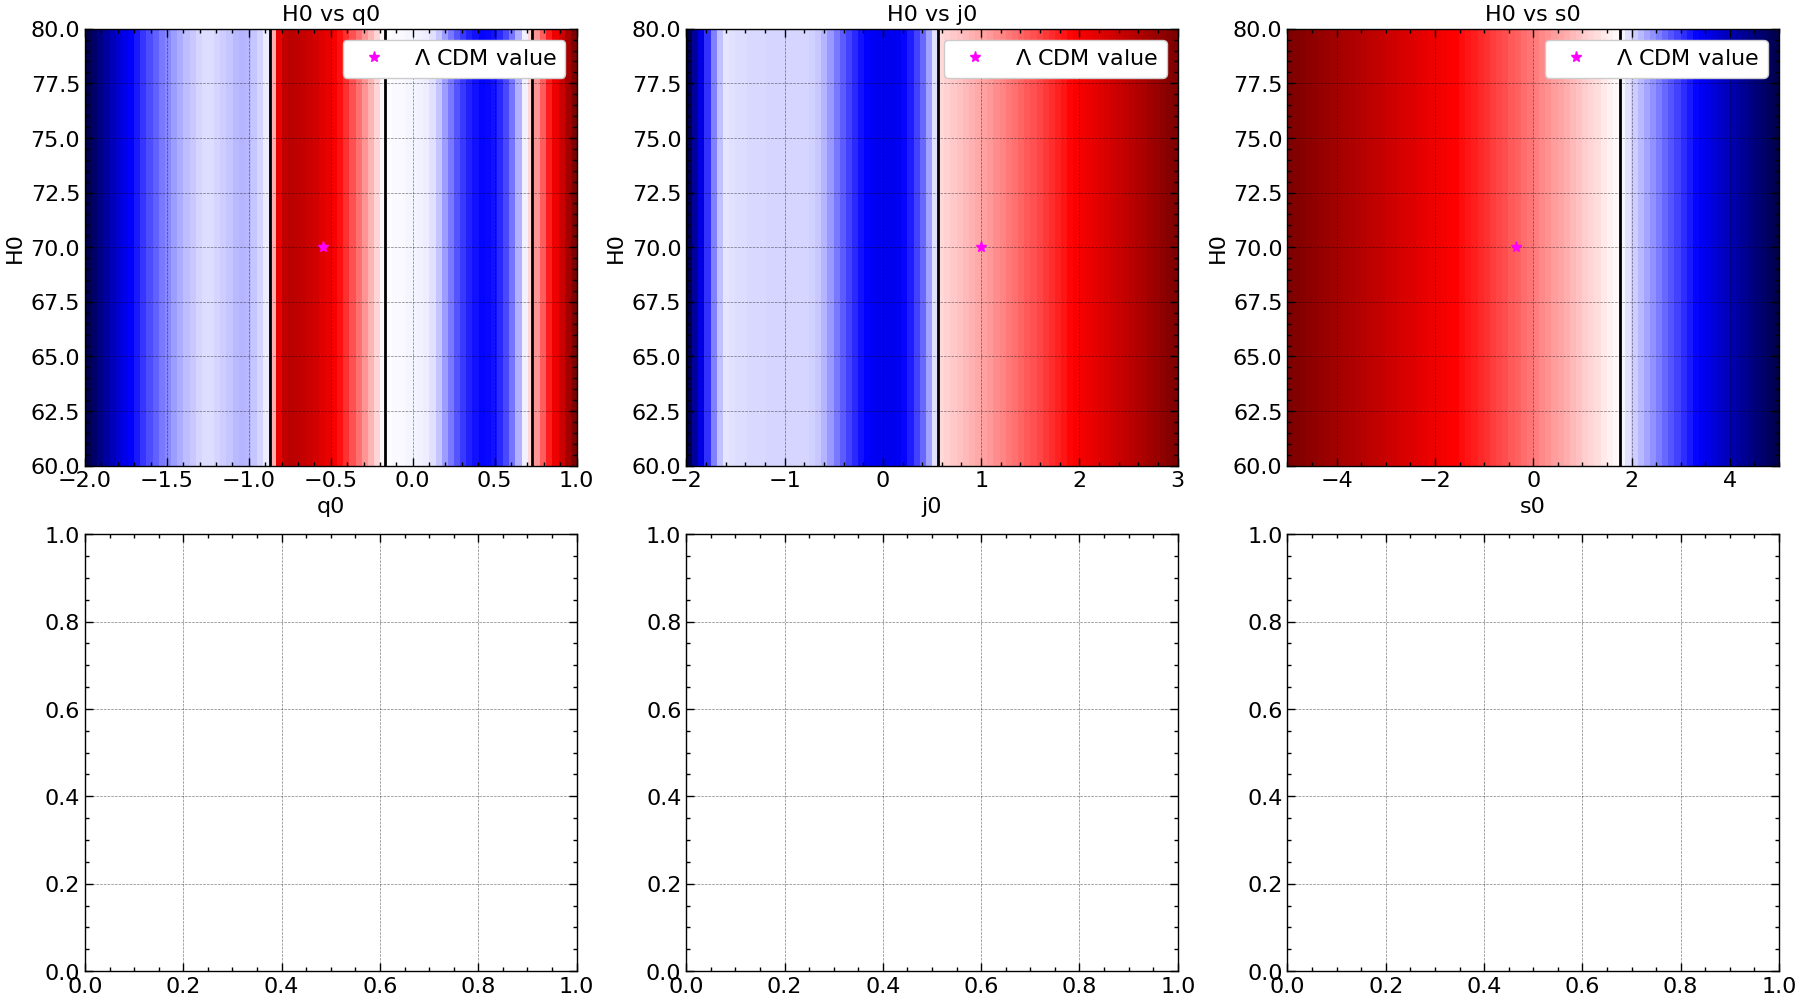

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (p1, r1, p2, r2) in zip(axes.flat, pairs):
    Z = stability_map(r1, r2, base, p1, p2)
    norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())
    img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                    extent=[r2.min(), r2.max(), r1.min(), r1.max()])
    ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
    ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    ax.set_title(f"{p1} vs {p2}")
    ax.legend()
fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="min(D(z)) (white = 0 line)")
plt.suptitle("Stability heatmaps: min Denominator for Pade 3,2 D(z)")
plt.show()

In [90]:
from itertools import combinations

E_ranges = {
    "E1": np.linspace(-1, 5, 80),
    "E2": np.linspace(-1, 5, 80),
    "E3": np.linspace(-5, 5, 80),
    "E4": np.linspace(-6, 5, 80),
    "E5": np.linspace(-5, 10, 80),
}
# Base values for E parameters
E_base = {
    "E1": 0.4500000000000002,
    "E2": 0.6975000000000002,
    "E3": -0.0416250000000012,
    "E4": -1.384593749999988,
    "E5": 3.405670312499811,
}

E_pairs = [
    (p1, E_ranges[p1], p2, E_ranges[p2])
    for p1, p2 in combinations(E_ranges.keys(), 2)
]

In [91]:
def eis_stability_map(p1_vals, p2_vals, fixed, p1_name, p2_name, order=6):
    z = np.linspace(0, 2.3, 400)
    Z = np.zeros((len(p1_vals), len(p2_vals)))
    for i, p1 in enumerate(p1_vals):
        for j, p2 in enumerate(p2_vals):
            params = fixed.copy()
            params[p1_name] = p1
            params[p2_name] = p2
            denom = eis_denominator(z, **params, order=order)
            Z[i, j] = np.min(denom)
    return Z

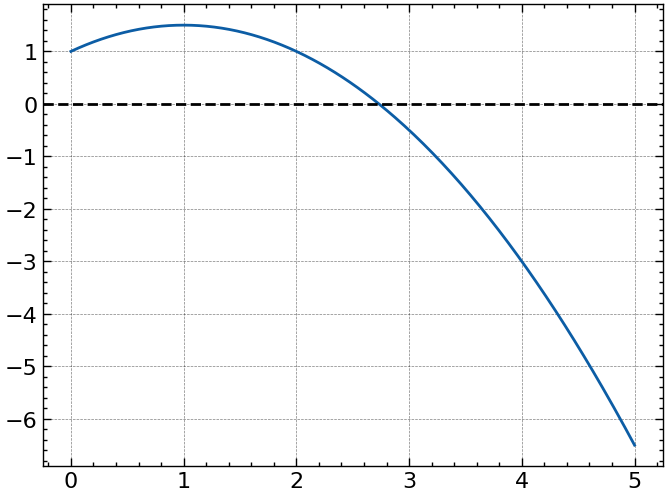

In [ ]:
plt.plot(z,eis_denominator(z, E1 = 1, E2=-1, E3=0, E4=0, E5=0, order=3))
plt.plot(z,eis_denominator(z, E1 = 1, E2=-1, E3=0, E4=0, E5=0, order=3))

plt.axhline(0, color='black', linestyle='--')

Generating EIS stability maps for order 3 with 1 rows and 2 columns.
['E1', 'E2']


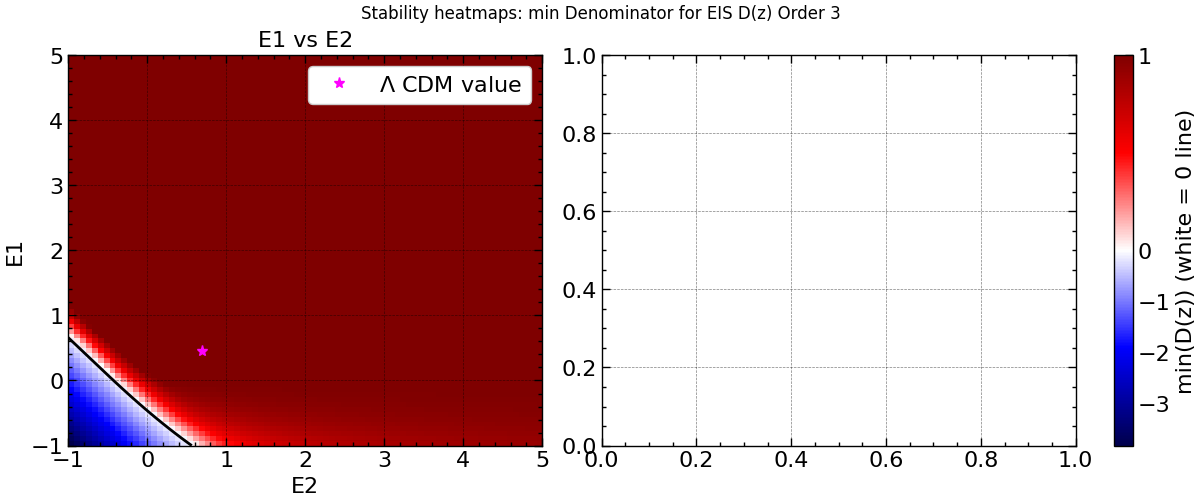

Generating EIS stability maps for order 4 with 1 rows and 3 columns.
['E1', 'E2', 'E3']


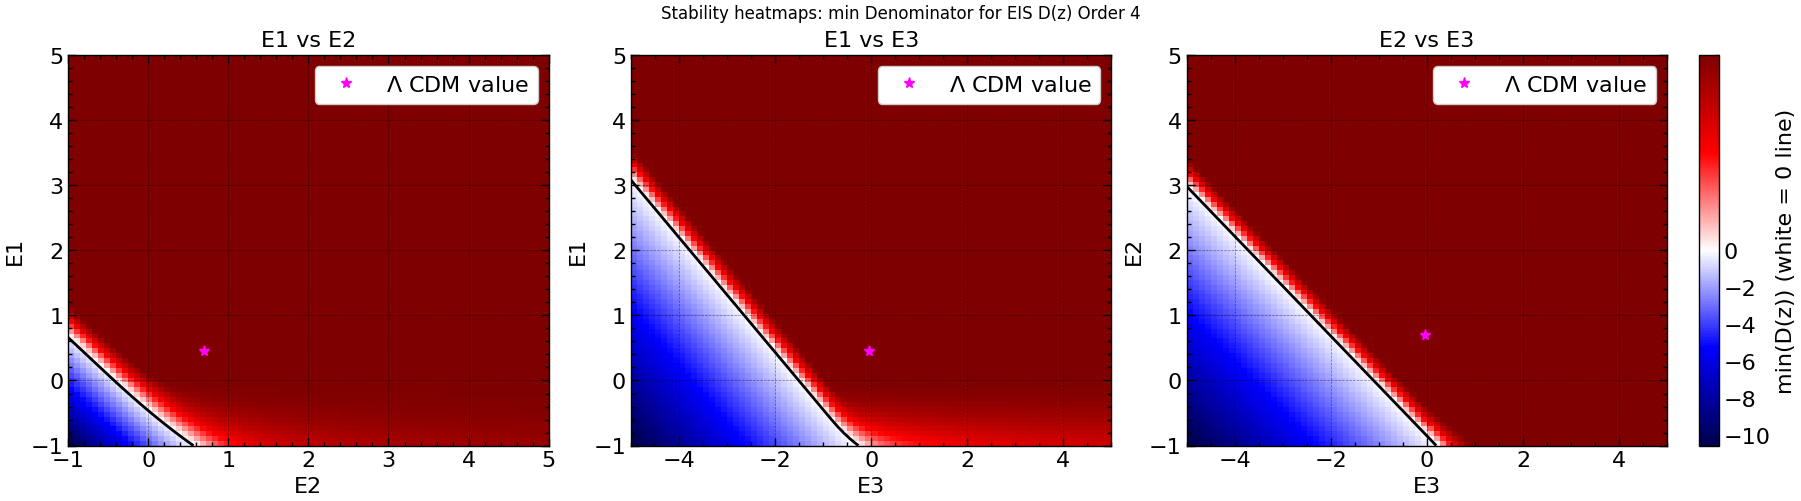

Generating EIS stability maps for order 5 with 2 rows and 3 columns.
['E1', 'E2', 'E3', 'E4']


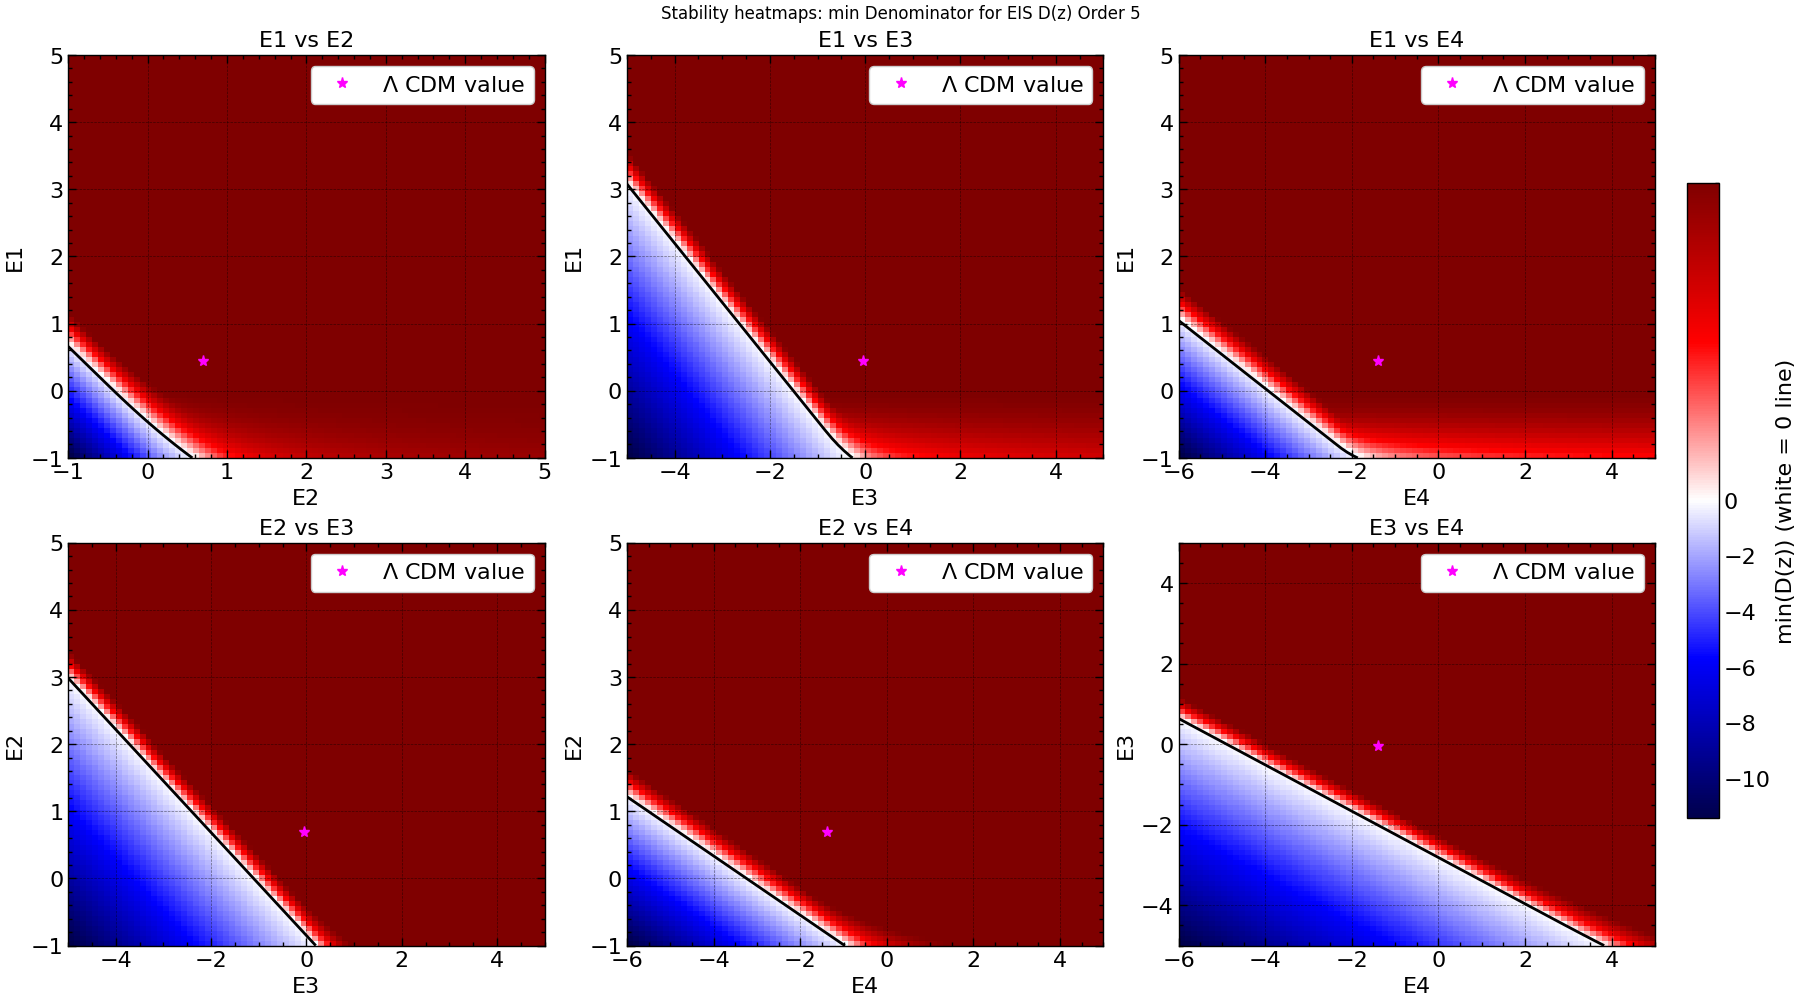

Generating EIS stability maps for order 6 with 4 rows and 3 columns.
['E1', 'E2', 'E3', 'E4', 'E5']


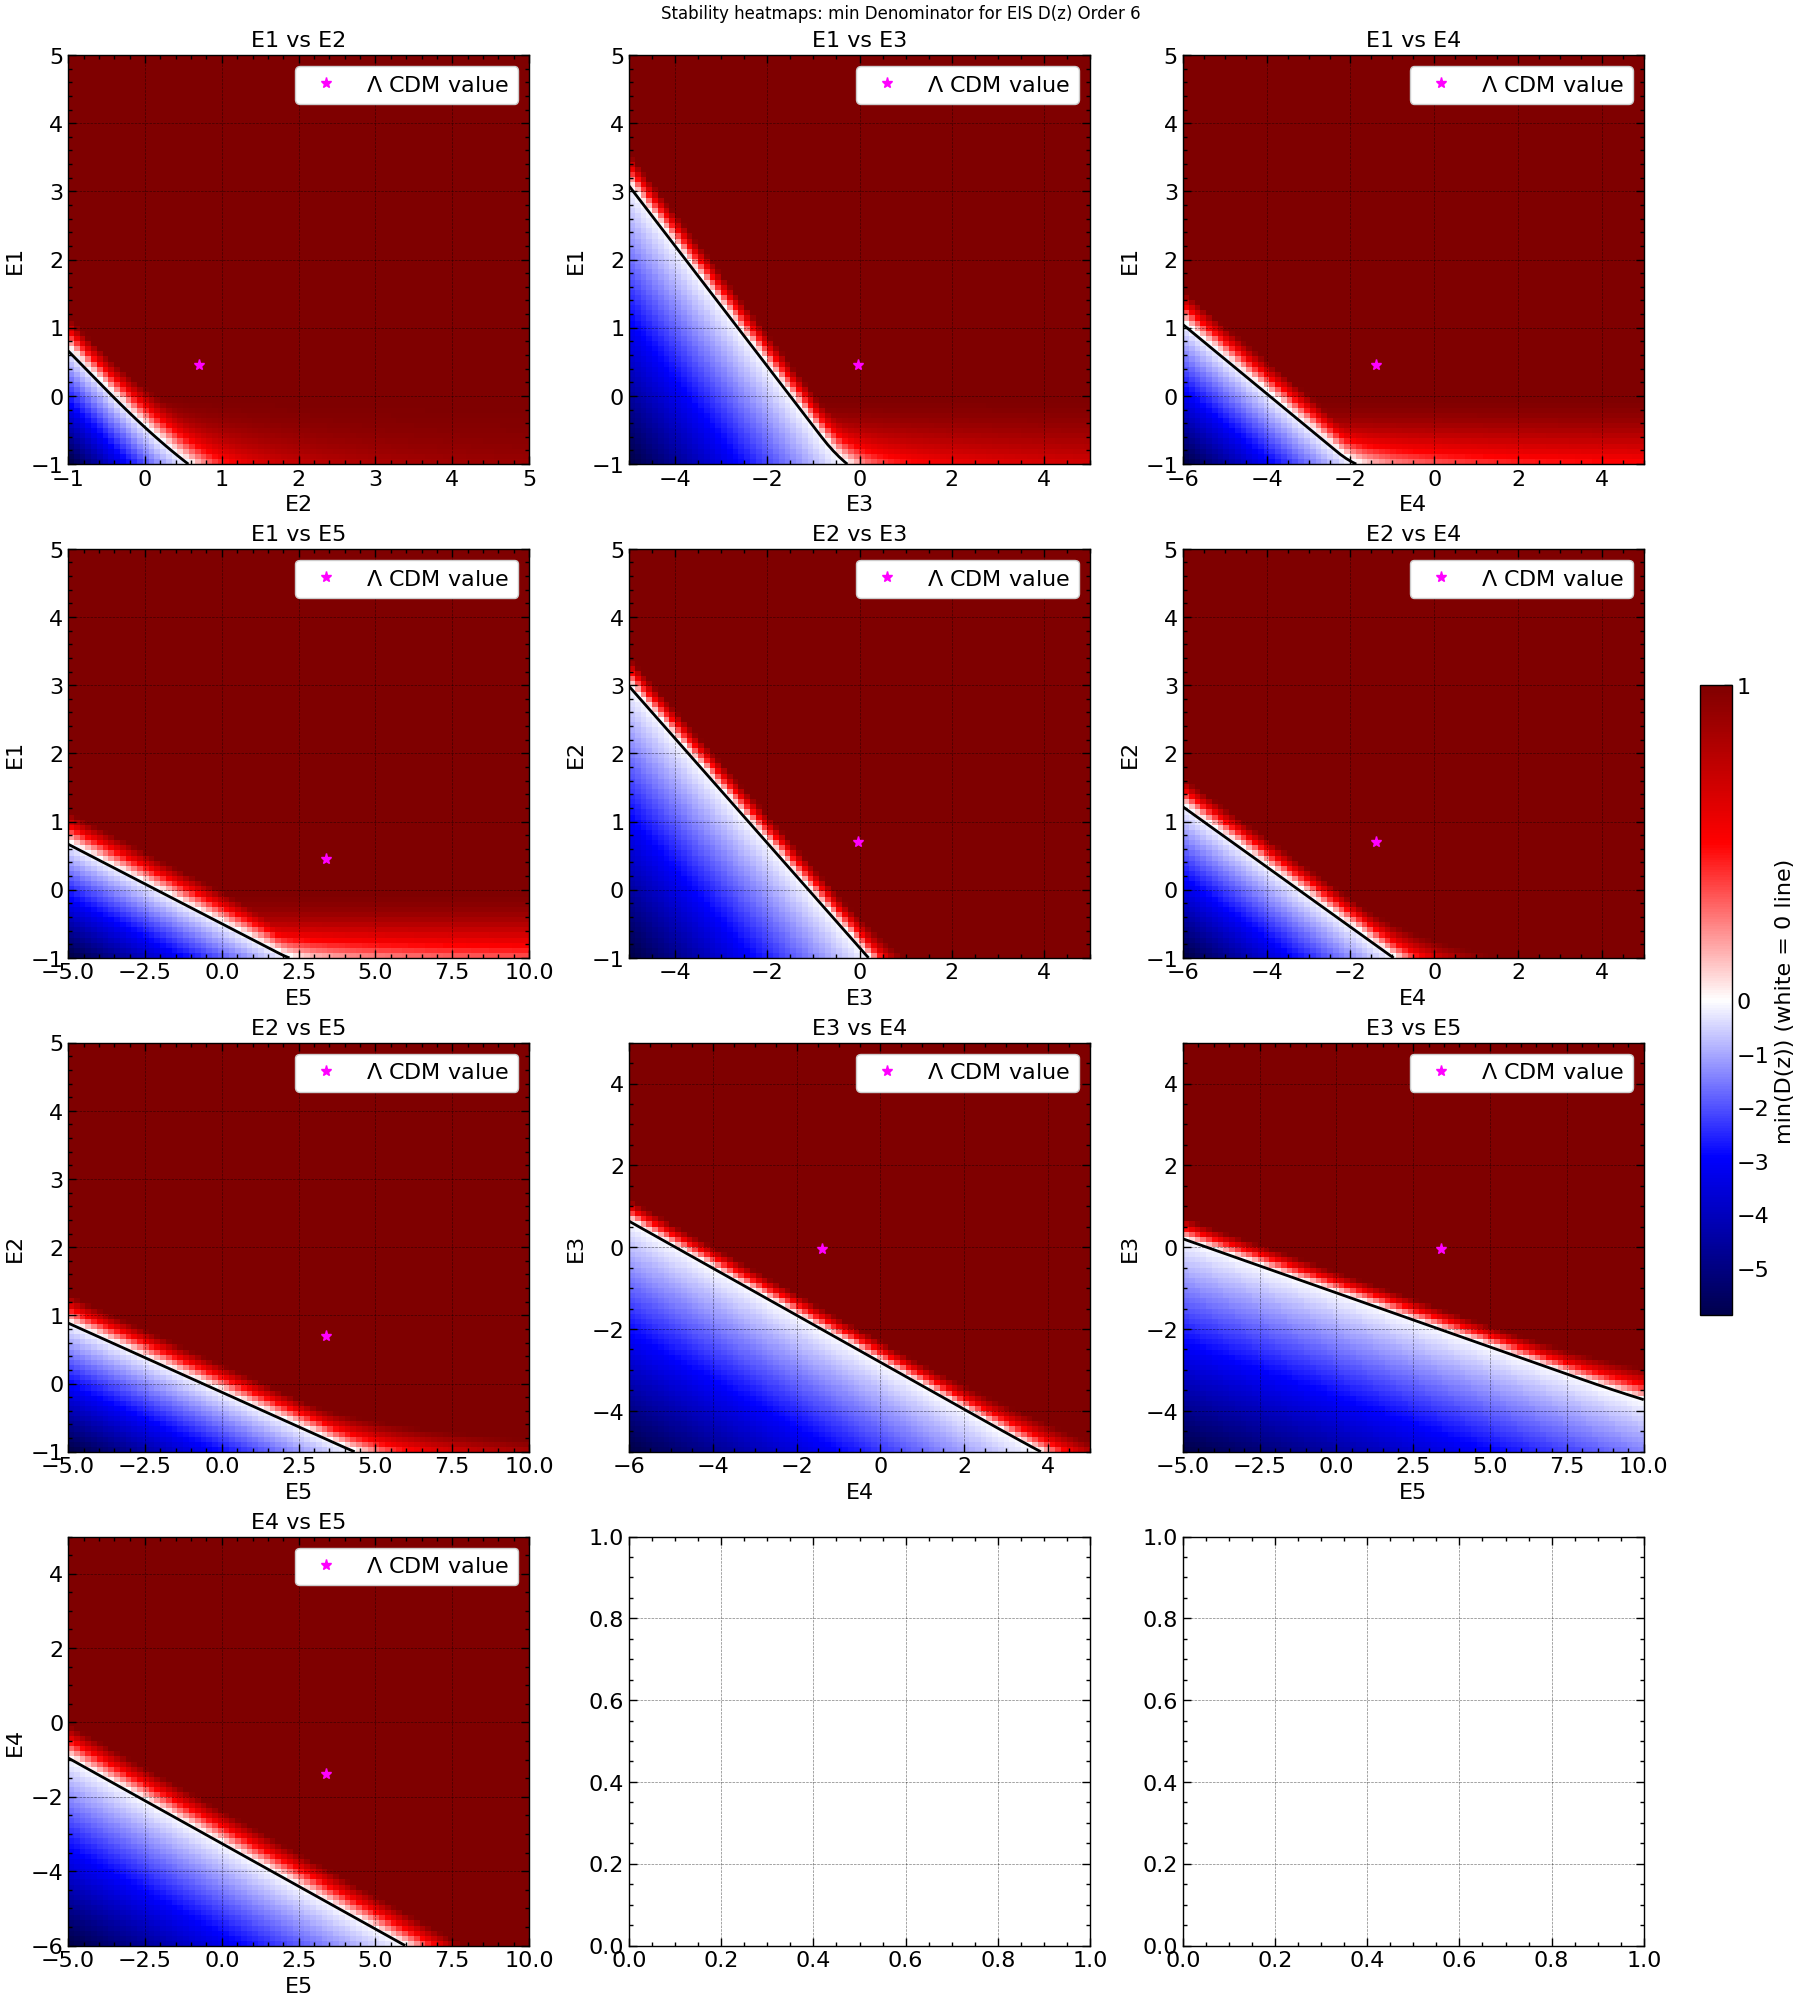

In [93]:
orders = [3,4,5,6]
for order in orders:
    columns = min(order-1,3 )

    rows = (math.comb(order-1,2) + columns - 1) // columns
    print(f"Generating EIS stability maps for order {order} with {rows} rows and {columns} columns.")
    
    fig, axes = plt.subplots(rows, columns, figsize=(6 * columns, 5 * rows), constrained_layout=True)

    params= list(E_base.keys())[:order-1]
    print(params)
    pairs  =  [(p1, E_ranges[p1], p2, E_ranges[p2]) for p1, p2 in combinations(params, 2)]

    for ax, (p1, r1, p2, r2) in zip(axes.flat, pairs):
        Z = eis_stability_map(r1, r2, E_base, p1, p2)
        norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())
        img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
        ax.plot(E_base[p2], E_base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
        ax.set_xlabel(p2)
        ax.set_ylabel(p1)
        ax.set_title(f"{p1} vs {p2}")
        ax.legend()
    fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="min(D(z)) (white = 0 line)")
    plt.suptitle("Stability heatmaps: min Denominator for EIS D(z) Order " + str(order))
    plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (p1, r1, p2, r2) in zip(axes.flat, pairs):
    Z = stability_map(r1, r2, base, p1, p2)
    norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())
    img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                    extent=[r2.min(), r2.max(), r1.min(), r1.max()])
    ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
    ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    ax.set_title(f"{p1} vs {p2}")
    ax.legend()
fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="min(D(z)) (white = 0 line)")
plt.suptitle("Stability heatmaps: min Denominator for Pade 3,2 D(z)")
plt.show()